# 05 Univariate Analysis

## Objective

Objective:
Perform univariate analysis to understand the distribution,
patterns, and characteristics of individual features.

This step helps in:
- Understanding data distribution
- Identifying skewness and outliers
- Detecting imbalance in categorical features
- Preparing for feature engineering and modeling


## Imports


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

project_root = Path.cwd()
if not (project_root / "src").exists() and (project_root.parent / "src").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.config import CATEGORICAL_COLUMNS, NUMERICAL_COLUMNS, TARGET_COLUMN
from src.data.data_loader import load_cleaned_data

sns.set_theme(style="whitegrid")


## Load Data and Separate Column Types


In [2]:
df = load_cleaned_data()
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
target_column = TARGET_COLUMN
numerical_columns = [column for column in NUMERICAL_COLUMNS if column in df.columns]
categorical_columns = [column for column in CATEGORICAL_COLUMNS if column in df.columns]
binary_columns = [
    column
    for column in categorical_columns
    if df[column].dropna().nunique() == 2
]

column_groups = {
    "numerical_columns": numerical_columns,
    "categorical_columns": categorical_columns,
    "binary_columns": binary_columns,
    "target_column": target_column,
}

column_groups


{'numerical_columns': ['tenure', 'MonthlyCharges', 'TotalCharges'],
 'categorical_columns': ['gender',
  'SeniorCitizen',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod'],
 'binary_columns': ['gender',
  'SeniorCitizen',
  'Partner',
  'Dependents',
  'PhoneService',
  'PaperlessBilling'],
 'target_column': 'Churn'}

## Target Column Analysis

Analyze the target column on its own to understand class counts, class percentages, and the degree of class imbalance before moving to feature-level analysis.


In [5]:
target_counts = df[target_column].value_counts().sort_index()
target_percentages = df[target_column].value_counts(normalize=True).sort_index().mul(100).round(2)

imbalance_ratio = round(target_counts.max() / target_counts.min(), 2)

if imbalance_ratio < 1.5:
    imbalance_level = "Low imbalance"
elif imbalance_ratio < 3:
    imbalance_level = "Moderate imbalance"
else:
    imbalance_level = "High imbalance"

target_summary = pd.DataFrame({
    "class_count": target_counts,
    "class_percentage": target_percentages,
})

display(target_summary)
print(f"Imbalance ratio (majority/minority): {imbalance_ratio}:1")
print(f"Imbalance level: {imbalance_level}")


,class_count,class_percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


Imbalance ratio (majority/minority): 2.77:1
Imbalance level: Moderate imbalance


/var/folders/1l/ddpthpdj6j75gsq02qk0x0kc0000gn/T/ipykernel_39113/933255990.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=target_column, order=target_counts.index, palette="Set2")


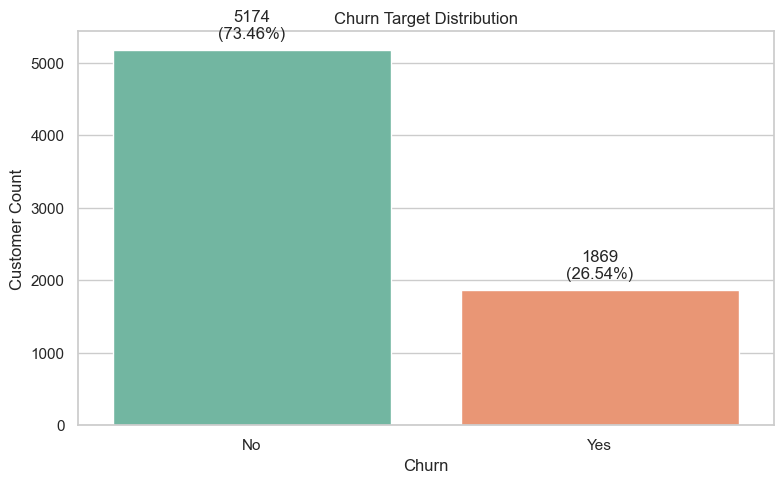

In [6]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x=target_column, order=target_counts.index, palette="Set2")

for patch, label in zip(ax.patches, target_counts.index):
    count = int(target_counts[label])
    percentage = target_percentages[label]
    ax.annotate(
        f"{count}\n({percentage}%)",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 6),
        textcoords="offset points",
    )

ax.set_title("Churn Target Distribution")
ax.set_xlabel(target_column)
ax.set_ylabel("Customer Count")
plt.tight_layout()
plt.show()


The target classes are moderately imbalanced. In this dataset, `No` is the majority class and `Yes` is the minority class, so downstream evaluation should rely on metrics beyond plain accuracy.


## Numerical Feature Analysis

Analyze each numerical feature on its own to understand central tendency, spread, skewness, and potential outliers.


In [7]:
numerical_summary = df[numerical_columns].describe().T
numerical_summary["median"] = df[numerical_columns].median()
numerical_summary["skew"] = df[numerical_columns].skew().round(2)
numerical_summary = numerical_summary[[
    "count",
    "mean",
    "median",
    "std",
    "min",
    "25%",
    "50%",
    "75%",
    "max",
    "skew",
]].round(2)

display(numerical_summary)


,count,mean,median,std,min,25%,50%,75%,max,skew
tenure,7043.0,32.37,29.00,24.56,0.00,9.00,29.00,55.00,72.00,0.24
MonthlyCharges,7043.0,64.76,70.35,30.09,18.25,35.50,70.35,89.85,118.75,-0.22
TotalCharges,7043.0,2279.73,1394.55,2266.79,0.00,398.55,1394.55,3786.60,8684.80,0.96


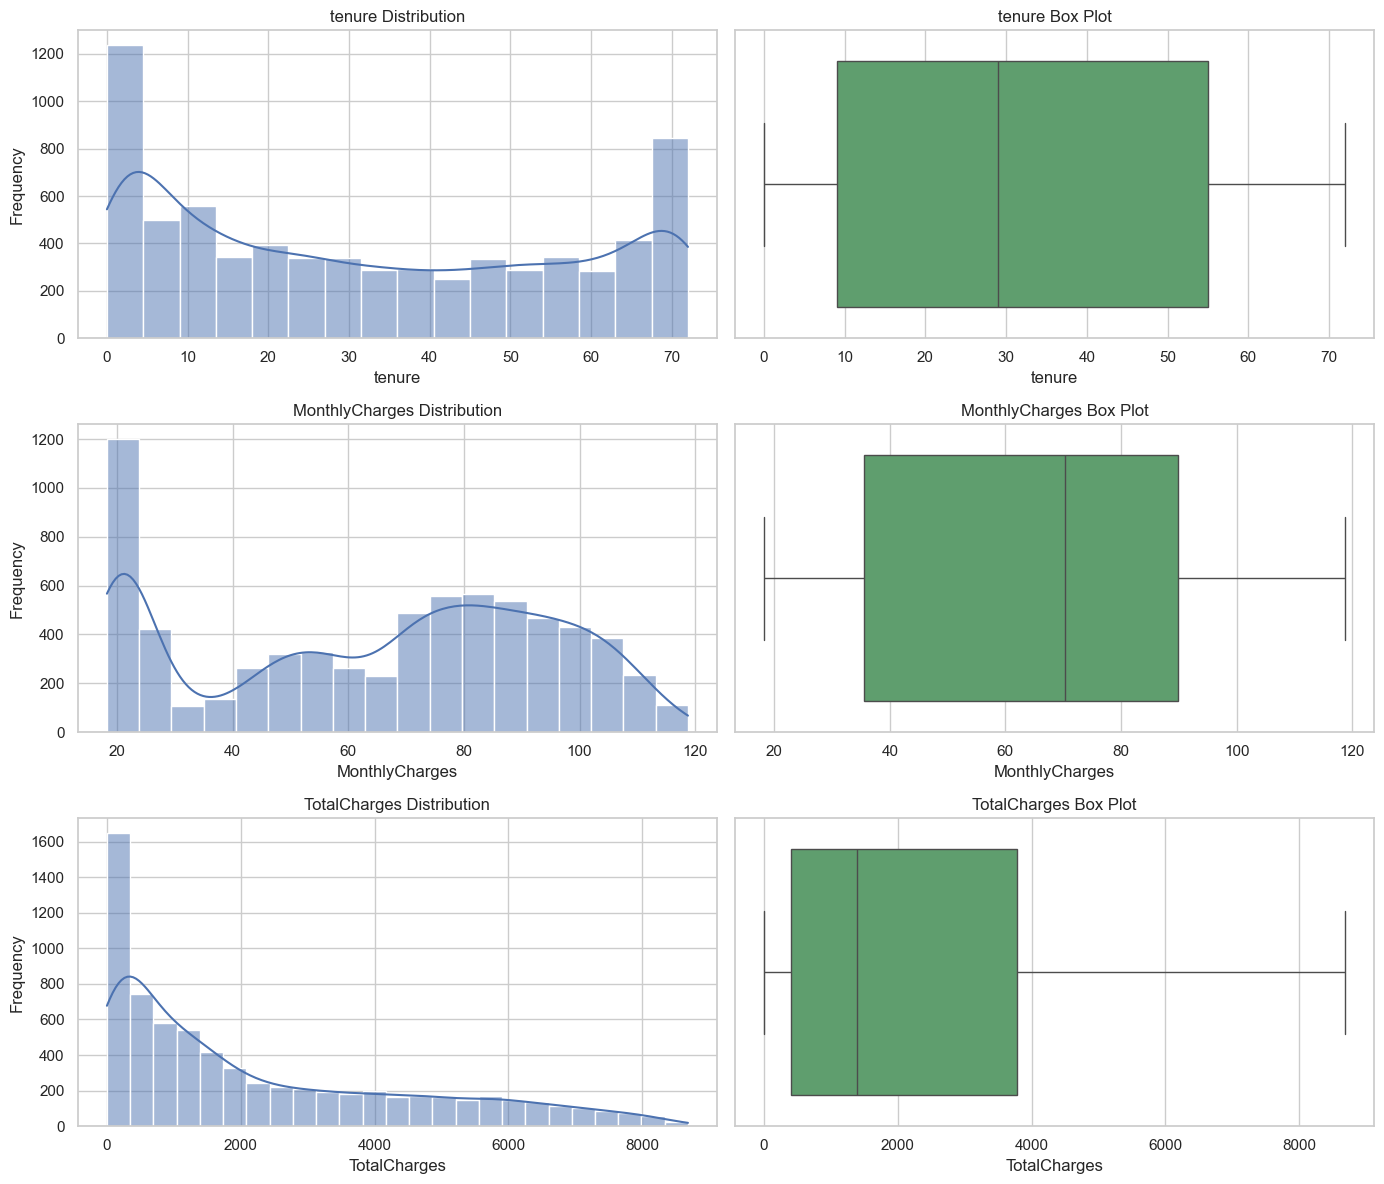

In [8]:
fig, axes = plt.subplots(len(numerical_columns), 2, figsize=(14, 4 * len(numerical_columns)))

if len(numerical_columns) == 1:
    axes = [axes]

for index, column in enumerate(numerical_columns):
    hist_ax, box_ax = axes[index]

    sns.histplot(data=df, x=column, kde=True, ax=hist_ax, color="#4C72B0")
    hist_ax.set_title(f"{column} Distribution")
    hist_ax.set_xlabel(column)
    hist_ax.set_ylabel("Frequency")

    sns.boxplot(data=df, x=column, ax=box_ax, color="#55A868")
    box_ax.set_title(f"{column} Box Plot")
    box_ax.set_xlabel(column)

plt.tight_layout()
plt.show()


In [10]:
outlier_summary = []

for column in numerical_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = df[(df[column] < lower_bound) | (df[column] > upper_bound)].shape[0]

    outlier_summary.append({
        "feature": column,
        "q1": round(q1, 2),
        "q3": round(q3, 2),
        "iqr": round(iqr, 2),
        "lower_bound": round(lower_bound, 2),
        "upper_bound": round(upper_bound, 2),
        "outlier_count": outlier_count,
    })

display(pd.DataFrame(outlier_summary))


,feature,q1,q3,iqr,lower_bound,upper_bound,outlier_count
0,tenure,9.00,55.00,46.00,-60.00,124.00,0
1,MonthlyCharges,35.50,89.85,54.35,-46.02,171.38,0
2,TotalCharges,398.55,3786.60,3388.05,-4683.52,8868.67,0


The IQR-based outlier check shows that none of the numerical features falls outside the standard `1.5 x IQR` bounds, so there are no extreme outliers by this rule. `tenure` and `MonthlyCharges` are spread out but still well contained, while `TotalCharges` is more right-skewed without producing formal IQR outliers. This suggests that `TotalCharges` needs attention mainly for skewness and accumulation over time, not because of anomalous extreme points.

From the distribution plots, `tenure` and `MonthlyCharges` show low skew, while `TotalCharges` shows moderate right skew and should be watched more carefully. The box plots do not indicate visible extreme outliers under the IQR rule, and zeros are meaningful for features like `tenure` and `TotalCharges` because they can represent new customers with little or no service history.

Scaling may be useful later for distance-based or linear models because the numerical features are on different ranges, even when outliers are limited. A log transform is usually unnecessary for low-skew features, but it may help `TotalCharges` if you later use a model that is sensitive to skewed distributions.

Use the summary table, histograms, and box plots together. The table gives the main descriptive statistics, the histograms show distribution shape and skew, and the box plots plus IQR summary highlight potential outliers.
